In [1]:
# Load required libraries
library(broom)
library(dplyr)
library(mgcv)
library(ggplot2)
library(lubridate)
library(parallel)
library(mlflow)
library(plotly)
library(gratia)
library(readr)



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: nlme


Attaching package: ‘nlme’


The following object is masked from ‘package:dplyr’:

    collapse


This is mgcv 1.9-4. For overview type '?mgcv'.


Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union



Attaching package: ‘plotly’


The following object is masked from ‘package:ggplot2’:

    last_plot


The following object is masked from ‘package:stats’:

    filter


The following object is masked from ‘package:graphics’:

    layout




In [2]:
mlflow_set_tracking_uri("https://mlflow.analytics-dev.tapestry.com")

In [3]:
best_fit <- mlflow_download_artifacts(run_id = '420bf1d81fcc415da966bd4e905decbd',path = "model.rds")

In [4]:
best_model <- readRDS(best_fit)

In [5]:
associate_goals_df <- read_csv('data/associate_goals_df.csv')

Rows: 2689309 Columns: 30
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (5): SHIFT_TYPE, TIME_OF_DAY, CHNL_DESC, REGION_DESC, DISTRICT_DESC
dbl  (23): STORE_NUMBER, SALES_ASSOCIATE, NET_SALES_AMOUNT_DLABS, GROSS_SALE...
date  (2): BUSINESS_DATE, FIRST_SELLING_DAY

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [ ]:
head(associate_goals_df)

In [13]:
tenure_smooth <- smooth_estimates(best_model, select = "s(LOG_TENURE)")

In [14]:
best_model


Family: Tweedie(p=1.58) 
Link function: log 

Formula:
SALES_PER_GOAL_HOUR ~ s(LOG_TENURE, k = 4) + s(STORE_NUMBER, 
    bs = "re") + s(SALES_ASSOCIATE, bs = "re") + s(HOURS_SINCE_OPEN, 
    k = 4) + DAY_OF_WEEK + STORE_MANAGER_GOAL + IS_HOLIDAY_SEASON

Estimated degrees of freedom:
   2.92   74.13 1499.99    2.79  total = 1588.83 

fREML score: 348461     

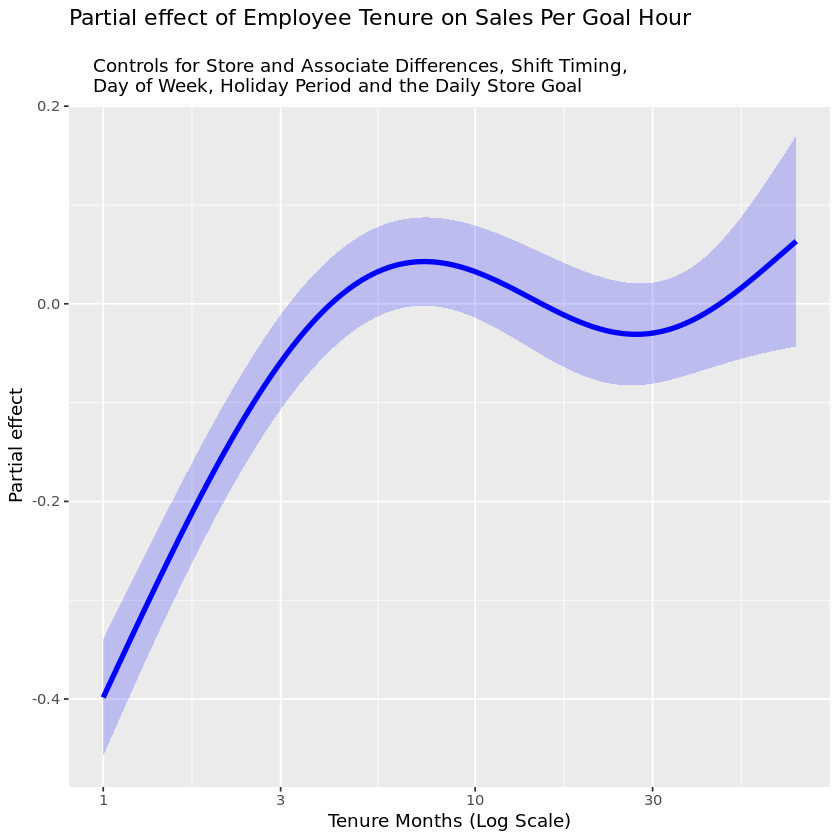

In [15]:
tenure_smooth |>
  add_confint() |>
  ggplot(aes(y = .estimate, x = exp(LOG_TENURE))) +
  geom_ribbon(aes(ymin = .lower_ci, ymax = .upper_ci),
    alpha = 0.2, fill = "blue"
  ) +
  geom_line(colour = "blue", linewidth = 1.5) +
  labs(
    y = "Partial effect",
    title = "Partial effect of Employee Tenure on Sales Per Goal Hour",
    subtitle = "
    Controls for Store and Associate Differences, Shift Timing,
    Day of Week, Holiday Period and the Daily Store Goal",
    x = "Tenure Months (Log Scale)"
  ) + scale_x_log10()

In [29]:
regression_df <- associate_goals_df %>%
       # Filter for valid goal hours and sales amounts
       filter(
              !is.na(GOALS_SCHEDULED_HOURS_CORRECTED),
              GOALS_SCHEDULED_HOURS_CORRECTED >= 4,
              GOALS_SCHEDULED_HOURS_CORRECTED <= 9,
              # GROSS_SALES_AMOUNT_DLABS >= 100,
              GROSS_SALES_AMOUNT_DLABS < quantile(associate_goals_df$GROSS_SALES_AMOUNT_DLABS, 0.99999, na.rm = TRUE),
              STORE_MANAGER_GOAL > 0,
              !is.na(HOURS_SINCE_OPEN)
       ) %>%
       mutate(
              YEAR = year(BUSINESS_DATE),
              TENURE_MONTHS = TENURE_DAYS / 30,
              SEASONAL_HIRE = ifelse(month(FIRST_SELLING_DAY) %in% c(11, 12), 1, 0),
              IS_HOLIDAY_SEASON = ifelse(MONTH %in% c(11, 12), 1, 0),
              IS_WEEKEND = ifelse(DAY_OF_WEEK %in% c(0, 5, 6), 1, 0),
              SALES_PER_GOAL_HOUR = GROSS_SALES_AMOUNT_DLABS / GOALS_SCHEDULED_HOURS_CORRECTED,
              LOG_TENURE = log(TENURE_MONTHS + 1),
              LOG_SALES = log(GROSS_SALES_AMOUNT_DLABS + 1)
       ) %>%
       # Select relevant columns
       select(
              SALES_ASSOCIATE, STORE_NUMBER, GROSS_SALES_AMOUNT_DLABS, STORE_MANAGER_GOAL,
              MONTH, DAY_OF_WEEK, WEEK_OF_YEAR, YEAR, TENURE_MONTHS,
              GOALS_SCHEDULED_HOURS_CORRECTED, SEASONAL_HIRE, IS_WEEKEND, IS_HOLIDAY_SEASON,
              CHNL_DESC, REGION_DESC, DISTRICT_DESC, SALES_PER_GOAL_HOUR, LOG_TENURE, LOG_SALES, HOURS_SINCE_OPEN,
              GOAL, BUSINESS_DATE
       )

regression_df <- regression_df %>%
    mutate(across(c(STORE_NUMBER, SALES_ASSOCIATE, MONTH, IS_WEEKEND, IS_HOLIDAY_SEASON,
                                    WEEK_OF_YEAR, YEAR, SEASONAL_HIRE, DAY_OF_WEEK, CHNL_DESC, 
                                    REGION_DESC, DISTRICT_DESC), 
                                as.factor))

In [18]:
new_df <- data_slice(best_model, LOG_TENURE = evenly(LOG_TENURE, lower = 0, upper = 4, n = 2000)) %>% mutate(.row = row_number())
fv <- fitted_values(best_model, data = new_df)

fs <- fitted_samples(best_model, data = new_df, n = 10, seed = 4) |>
  left_join(new_df |> select(.row, LOG_TENURE), by = join_by(.row == .row))

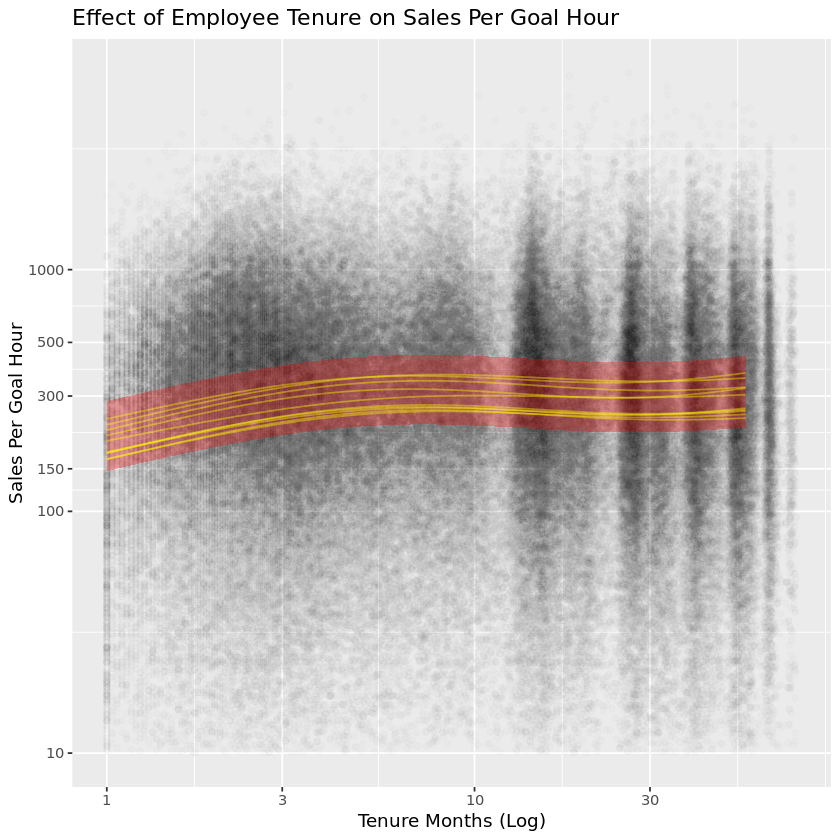

In [19]:
regression_df |>
  filter(log10(SALES_PER_GOAL_HOUR) > 1) |>
  ggplot(aes(x = exp(LOG_TENURE), y = SALES_PER_GOAL_HOUR)) +
  geom_point(alpha = 0.01)  +
  geom_ribbon(data = fv, aes(y = .fitted, ymin = .lower_ci, ymax = .upper_ci),
    fill = "red", alpha = 0.3) +
  geom_line(data = fs, aes(group = .draw, x = exp(LOG_TENURE), y = .fitted),
    colour = "yellow", alpha = 0.4) + 
    scale_y_log10(breaks = c(10, 100, 150, 300, 500, 1000)) + 
    scale_x_log10() + 
  labs(
    title = "Effect of Employee Tenure on Sales Per Goal Hour", 
    x = "Tenure Months (Log)",
    y = "Sales Per Goal Hour"
  )

In [20]:
ds <- data_slice(best_model, LOG_TENURE = evenly(LOG_TENURE, n = 50), DAY_OF_WEEK = evenly(DAY_OF_WEEK), .observed_only = TRUE)

In [30]:
fitted_df <- fitted_values(best_model, data = regression_df)

Warning message in predict.gam(object, newdata = newdata, type = "newdata", se.fit = se.fit, :
“factor levels 1101, 1104, 1105, 1205, 1206, 1208, 1209, 1211, 1218, 1220, 1252, 1266, 1270, 1271, 1274, 1300, 1306, 1350, 1401, 1404, 1407, 1409, 1410, 1412, 1425, 1436, 1450, 1455, 1505, 1608, 1651, 1653, 1654, 1751, 1951, 1953, 2002, 2006, 2052, 2053, 2056, 2100, 2103, 2108, 2200, 2201, 2204, 2300, 2451, 2454, 2455, 2459, 2460, 2502, 2507, 2554, 2561, 2575, 2579, 2600, 2601, 2700, 2701, 2704, 2751, 2801, 2803, 2856, 2952, 3101, 3104, 3108, 3111, 3115, 3119, 3147, 3252, 3301, 3551, 3601, 3702, 3704, 3801, 3802, 3803, 3808, 3809, 3810, 3811, 3812, 3814, 3816, 3817, 3819, 3821, 3823, 3825, 3827, 3828, 3831, 3832, 3834, 3853, 3854, 3900, 3901, 4001, 4002, 4004, 4006, 4007, 4009, 4011, 4018, 4019, 4020, 4051, 4052, 4053, 4054, 4055, 4056, 4201, 4251, 4252, 4270, 4320, 4321, 4500, 4501, 4601, 4603, 4604, 4605, 4652, 4701, 4703, 4705, 4706, 4707, 4802, 4852, 4900, 4901, 4920, 5000, 5002, 5050, 50

In [42]:
fitted_df %>% 
group_by(BUSINESS_DATE, STORE_NUMBER, SALES_ASSOCIATE) %>% 
summarize(OLD_GOALS = sum(GOAL), NEW_GOALS = sum(.fitted * GOALS_SCHEDULED_HOURS_CORRECTED), ACTUAL_SALES = sum(GROSS_SALES_AMOUNT_DLABS), STORE_GOAL = first(STORE_MANAGER_GOAL)) %>% 
group_by() %>%
summarize(RMSE_OLD = sqrt(mean((ACTUAL_SALES - OLD_GOALS)^2)), RMSE_NEW = sqrt(mean((ACTUAL_SALES - NEW_GOALS)^2)))

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by BUSINESS_DATE, STORE_NUMBER, and
  SALES_ASSOCIATE.
ℹ Output is grouped by BUSINESS_DATE and STORE_NUMBER.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(BUSINESS_DATE, STORE_NUMBER, SALES_ASSOCIATE))` for
  per-operation grouping (`?dplyr::dplyr_by`) instead.


RMSE_OLD,RMSE_NEW
<dbl>,<dbl>
2095.529,4000.552


In [23]:
rmse <- scored_df %>%
  summarise(
    rmse = sqrt(mean((SALES_PER_GOAL_HOUR - pred_sales_per_goal_hour)^2, na.rm = TRUE))
  ) %>%
  pull(rmse)

rmse

[1] 581.0044

In [24]:
mape <- scored_df %>%
  filter(SALES_PER_GOAL_HOUR > 0) %>%
  summarise(
    mape = mean( abs(SALES_PER_GOAL_HOUR - pred_sales_per_goal_hour) / SALES_PER_GOAL_HOUR, na.rm = TRUE) * 100
  ) %>%
  pull(mape)

mape

[1] 264.1361